<a href="https://colab.research.google.com/github/ConradKatlegoMogane/Data-Dump-For-all-things-useful-/blob/main/Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Linear Regression Analysis on Used Car Dataset**

This project explores the relationship between a vehicle’s age and its corresponding mileage and market price using linear regression models. Based on data from 1,821 used cars, we calculate age by subtracting the manufacturing year from the year the data was collected. The study focuses on vehicles under 20 years old and applies regression techniques to:

- Examine how **mileage increases** with age,
- Understand how **price depreciates** over time, and
- Evaluate model performance through statistical metrics such as **R², p-values, and standard errors**.

Visualizations and regression summaries help highlight trends that are crucial for consumers, dealers, and data analysts interested in automotive valuation and forecasting.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
from scipy.stats import linregress
import matplotlib.pyplot as plt
#Loading set
df = pd.read_excel(r"/content/drive/MyDrive/buyable2023.xlsx",
                   usecols = ['Year', 'Make', 'Car_Model', 'Price', 'Mileage', 'Year_Data_Collected'])

#Feature engineering
#Age Normoilization
df['Age'] = df['Year_Data_Collected'] - df['Year']
# Data Preview
print('Size of data is ',len(df),'rows and ',len(df.columns), 'columns ')
print(df.info())

Size of data is  1821 rows and  7 columns 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1821 entries, 0 to 1820
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Make                 1821 non-null   object
 1   Car_Model            1821 non-null   object
 2   Price                1821 non-null   int64 
 3   Mileage              1821 non-null   int64 
 4   Year                 1821 non-null   int64 
 5   Year_Data_Collected  1821 non-null   int64 
 6   Age                  1821 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 99.7+ KB
None


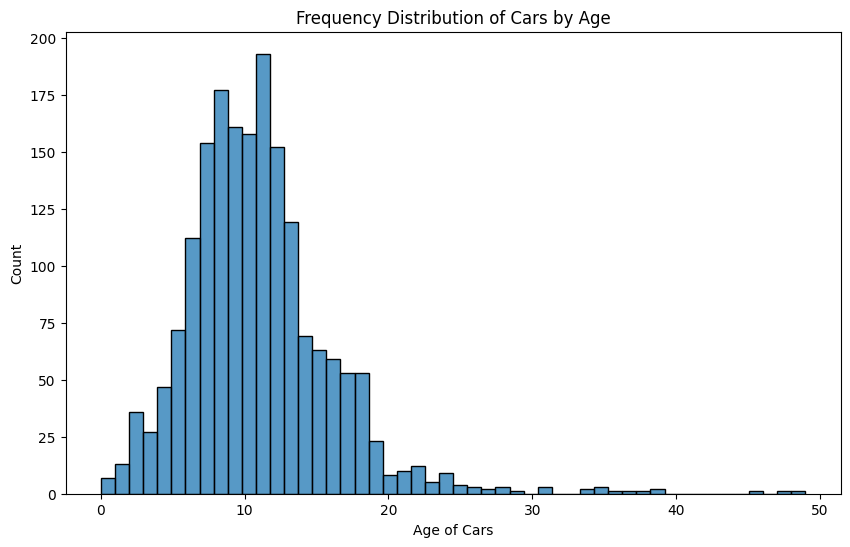

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df,x='Age',)
plt.title('Frequency Distribution of Cars by Age')
plt.xlabel('Age of Cars')
plt.xscale('linear')

**there are few cars after 20 years in age for analysis these will excluded.**

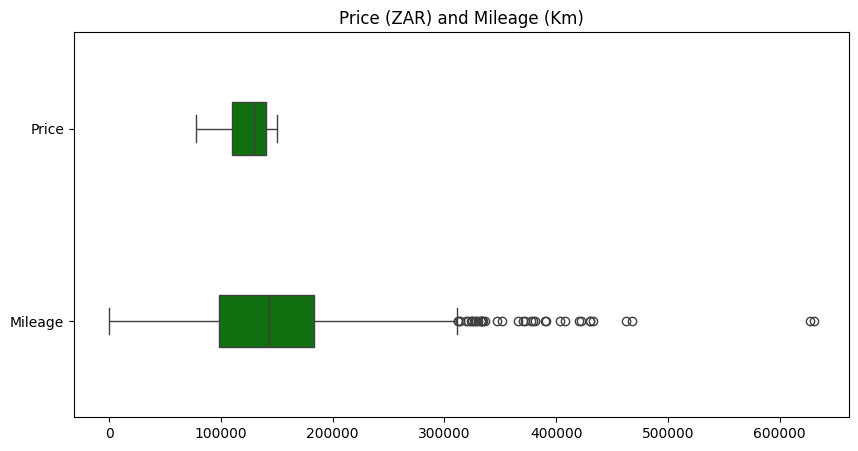

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Price', 'Mileage']], width=0.275, color= 'g', orient='h')
plt.title('Price (ZAR) and Mileage (Km)')
plt.show()

In [ ]:
# Data Preview
print('Size of data is ',len(cars),'rows and ',len(cars.columns), 'columns ')

Size of data is  1748 rows and  7 columns 


**Regression Analysis**
1. Mileage v.s Age of Car
2. Price v.s Age of Car

In [ ]:
cars.head(5)

,Make,Car_Model,Price,Mileage,Year,Year_Data_Collected,Age
0,RENAULT,RENAULT CAPTUR 900T BLAZE 5DR (66KW),149950,96000,2017,2023,6
1,NISSAN,NISSAN MICRA 1.2 VISIA+ AUDIO 5DR (D86V),129950,22000,2017,2023,6
2,KIA,KIA PICANTO 1.2 LS,114999,70000,2017,2023,6
3,VOLKSWAGEN,VOLKSWAGEN POLO VIVO 1.4 5Dr,124995,166134,2014,2023,9
4,FORD,FORD FIGO 1.4 AMBIENTE,82995,162123,2013,2023,10


## Mileage v Age of Car

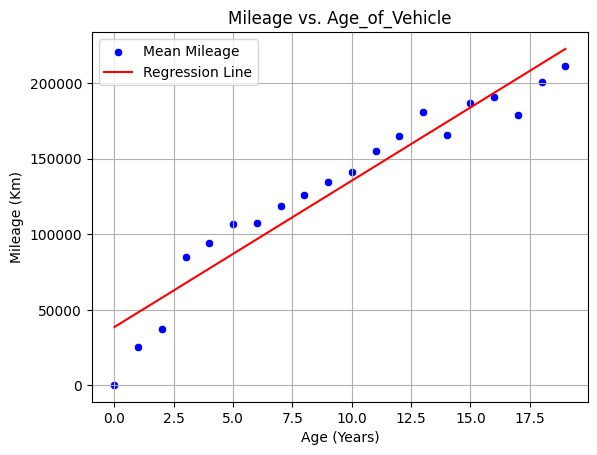

Mileage Regression equation: y = 9675.62x + 38622.29 

R² = 0.921 | P-value = 0.000 | Std Error = 665.639 | intercept = 38622.29 | Slope = 9675.62 

                            OLS Regression Results                            
Dep. Variable:           mean_mileage   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     211.3
Date:                Fri, 04 Jul 2025   Prob (F-statistic):           2.18e-11
Time:                        08:56:10   Log-Likelihood:                -222.34
No. Observations:                  20   AIC:                             448.7
Df Residuals:                      18   BIC:                             450.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [

In [ ]:
cars_km = cars.groupby('Age')['Mileage'].aggregate(['mean', 'std', 'count']).round(2).reset_index()
cars_km.rename(columns={'mean': 'mean_mileage', 'std': 'std_mileage', 'count': 'count_km'}, inplace=True)
# Regression Analysis
##y = cars_km['mean']
# Add constant for intercept
#X = sm.add_constant(X)
x = sm.add_constant(cars_km['Age'])
model_km = sm.OLS(cars_km['mean_mileage'],x).fit()
# Compute regression variables
result_km = linregress(cars_km['Age'],cars_km['mean_mileage'])
slope_km = result_km.slope
intercept_km = result_km.intercept
r_value_km = result_km.rvalue
p_value_km = result_km.pvalue
std_err_km = result_km.stderr

# Plotting the regression line
sns.scatterplot(x=cars_km['Age'], y=cars_km['mean_mileage'], color='blue', label='Mean Mileage')
sns.lineplot(x=cars_km['Age'], y=slope_km * cars_km['Age'] + intercept_km, color='red',
             label='Regression Line')
plt.xlabel("Age (Years)")
plt.ylabel("Mileage (Km)")
plt.title("Mileage vs. Age_of_Vehicle")
plt.legend()
plt.grid()
plt.show()


print(f"Mileage Regression equation: y = {slope_km:.2f}x + {intercept_km:.2f}",'\n')
print(f"R² = {r_value_km**2:.3f}",'|', f"P-value = {p_value_km:.3f}",'|',
      f"Std Error = {std_err_km:.3f}",'|',f"intercept = {intercept_km:.2f}",'|',
      f"Slope = {slope_km:.2f}",'\n')
print('==============================================================================')
print(model_km.summary())

## Price v Age of Car

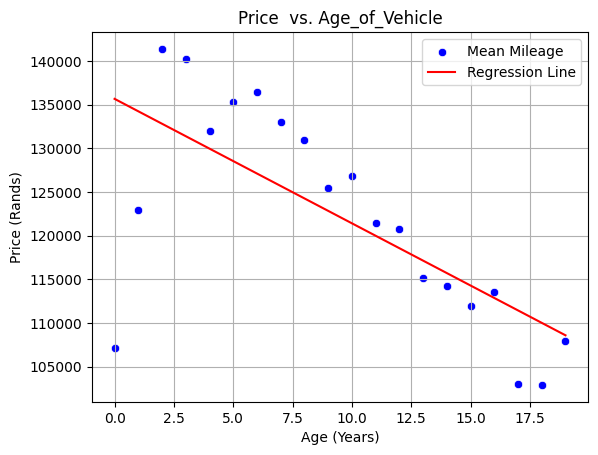

Price Regression equation: y = -1424.50x + 135650.29 

R² = 0.472 | P-value = 0.001 | Std Error = 354.783 | intercept = 135650.29 | Slope = -1424.50 

                            OLS Regression Results                            
Dep. Variable:             mean_price   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     16.12
Date:                Fri, 04 Jul 2025   Prob (F-statistic):           0.000812
Time:                        08:56:10   Log-Likelihood:                -209.75
No. Observations:                  20   AIC:                             423.5
Df Residuals:                      18   BIC:                             425.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|     

In [ ]:
cars_price = cars.groupby('Age')['Price'].aggregate(['mean', 'std', 'count']).round(2).reset_index()
cars_price.rename(columns={'mean': 'mean_price', 'std': 'std_price', 'count': 'count_price'}, inplace=True)
# Regression Analysis
# Add constant for intercept for analysis
x1 = sm.add_constant(cars_price['Age'])
model_price = sm.OLS(cars_price['mean_price'], x1).fit()
# Compute regression variables
result_price = linregress(cars_price['Age'],cars_price['mean_price'])
slope_price = result_price.slope
intercept_price = result_price.intercept
r_value_price = result_price.rvalue
p_value_price = result_price.pvalue
std_err_price = result_price.stderr

# Plotting the regression line
sns.scatterplot(x=cars_price['Age'], y=cars_price['mean_price'], color='blue', label='Mean Mileage')
sns.lineplot(x=cars_price['Age'], y=slope_price * cars_price['Age'] + intercept_price, color='red',
             label='Regression Line')
plt.xlabel("Age (Years)")
plt.ylabel("Price (Rands)")
plt.title("Price  vs. Age_of_Vehicle")
plt.legend()
plt.grid()
plt.show()


print(f"Price Regression equation: y = {slope_price:.2f}x + {intercept_price:.2f}",'\n')
print(f"R² = {r_value_price**2:.3f}",'|', f"P-value = {p_value_price:.3f}",'|',
      f"Std Error = {std_err_price:.3f}",'|',f"intercept = {intercept_price:.2f}",'|',
      f"Slope = {slope_price:.2f}",'\n')
print(model_price.summary())

## **Summary of Key Points:**
**Dataset Overview:**



*  Dataset Size: 1821 rows and 7 columns. ​
*  Columns: Make, Car_Model, Price, Mileage, Year, Year_Data_Collected, Age.
*  Age Calculation: Age = Year_Data_Collected - Year.


**Filtered Dataset**:
Cars with Age 20 were filtered, resulting in 1748 rows. based sales recommendation from reputable [sources.](https://) ​



**Regression Analysis:**

---



**Mileage vs. Age of Car:** ​

* Regression Equation: y = 9675.62x + 38622.29. ​

* R² (Coefficient of Determination): 0.921 (indicating a strong relationship). ​
* P-value: 0.000 (statistically significant).
* Std Error: 665.639.
* Slope: 9675.62 (Mileage increases by ~9675.62 km per year of age). ​
* Intercept: 38622.29.


---



**Price vs. Age of Car:** ​

* Regression Equation: y = -1424.50x + 135650.29. ​
* R²: 0.472 (moderate relationship). ​
* P-value: 0.001 (statistically significant). ​
* Std Error: 354.783.
* Slope: -1424.50 (Price decreases by ~1424.50 Rands per year of age). ​
* Intercept: 135650.29.



---



**Observations:**

* Mileage: Strong positive correlation with car age. ​
* Price: Moderate negative correlation with car age.

**Statistical Model Details:**

**Mileage Regression:** ​

* Adjusted R²: 0.917. ​
* F-statistic: 211.3 (high significance). ​
* Durbin-Watson: 0.617 (indicating potential autocorrelation). ​


**Price Regression:** ​

* Adjusted R²: 0.443. ​
* F-statistic: 16.12. ​
* Durbin-Watson: 0.643. ​



---



**Visualizations:**

Scatter plots and regression lines were plotted for both Mileage vs. Age and Price vs. Age. ​

This analysis highlights the trends in mileage and price as cars age, with mileage increasing and price decreasing over time.